In [494]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [495]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os


In [496]:
dataset_name = "HD"

model_name = 'LR'

dataset_combo = "CL_HG"

save_tables = 1

key_1 = 5
key_2 = 11
key_3 = 21
key_4 = 31
key_5 = 41
key_6 = 50

# key_1 = 3
# key_2 = 5
# key_3 = 11
# key_4 = 21
# key_5 = 31
# key_6 = 41

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#984ea3', '#e41a1c', '#a65628']

count_plot_print=1

# red, blue, green, orange, pink, yellow

In [497]:
base_dataset_name = dataset_combo.split("_")[0]
derived_dataset_name =  dataset_combo.split("_")[1]

match base_dataset_name:
        case 'CL':
            base_dataset = "Cleveland"
            len_base = 303

        case 'HG':
            base_dataset = "Hungary"
            len_base = 294

        case 'SW':
            base_dataset = "Switzerland"
            len_base = 123
        
        case 'VA':
            base_dataset = "Long Beach VA"
            len_base = 200

        case 'A':
            base_dataset = "AI Set A"
            len_base = 1665

        case _:
            raise SystemExit("Valid name of base dataset is not provided")
     
match derived_dataset_name:
        case 'CL':
            derived_dataset = "Cleveland"
            len_derived = 303

        case 'HG':
            derived_dataset = "Hungary"
            len_derived = 294

        case 'SW':
            derived_dataset = "Switzerland"
            len_derived = 123
            
        case 'VA':
            derived_dataset = "Long Beach VA"
            len_derived = 200

        case 'B':
            derived_dataset = "AI Set B"
            len_base = 699

        case _:
            raise SystemExit("Valid name of derived dataset is not provided")

In [498]:
# !ls ../../Final_Results/HD/CL_HG/


In [499]:
path = './Final_Results/'+dataset_name+"/"+dataset_combo+"/"+model_name+"/"
path

'./Final_Results/HD/CL_HG/LR/'

In [500]:
dfs = {key_1:{}, key_2:{}, key_3:{}, key_4:{}, key_5:{}, key_6:{}}
       

isExist = os.path.exists(path)

if isExist:
    for file_name in os.listdir(path):
        if file_name.endswith(".csv") and any(file_name.startswith(str(key)+"_") for key in dfs.keys()):
            with open(path+file_name, 'r') as file:
                df = pd.read_csv(file)
                
                num_models = int(file_name.split('_')[0])
                
                agreement_rate = float(file_name.split('_')[-3])

                # print(num_models, agreement_rate)
                dfs[num_models][agreement_rate] = df
        
    derived_label_match_results = {key_1:{}, key_2:{}, key_3:{}, key_4:{}, key_5:{}, key_6:{}}
    reverse_label_match_original_results = {key_1:{}, key_2:{}, key_3:{}, key_4:{}, key_5:{}, key_6:{}}

    for num_models in dfs:
        for agreement_rate in dfs[num_models]:
            try:
                df = dfs[num_models][agreement_rate]

                match_for = 'label match with the origial labels for '+derived_dataset
                derived_label_match = df.loc[df['description']==match_for]['value'].item()

                # match_for = 'Train on original '+base_dataset+' test on original '+derived_dataset
                match_for = 'Reverse derived label match with original labels for '+base_dataset

                reverse_label_match_original = df.loc[df['description']==match_for]['value'].item()
                # derived_label_match = df.loc['label match with the origial labels for ' in df['description']]['value'].item()
                # derived_label_match = derived_label_match.split('\n')[1]
        #         derived_label_match = [x.split(' ')[0] for x in derived_label_match]
                derived_label_match_results[num_models][agreement_rate] = derived_label_match
                reverse_label_match_original_results[num_models][agreement_rate] = reverse_label_match_original
            except:
                print(f'Failed for {num_models}, {agreement_rate}')

    for num_models in derived_label_match_results:
        derived_label_match_results[num_models] = dict(sorted(derived_label_match_results[num_models].items()))
        reverse_label_match_original_results[num_models] = dict(sorted(reverse_label_match_original_results[num_models].items()))
else:
    raise SystemExit("\n\nPath does not exist!\n\n")



In [501]:
pd.set_option('display.max_colwidth', None)

In [502]:
num_models, agreement_rate

(50, 0.9)

In [503]:
df

,s_no,description,value
0,1.1,Train-test on Cleveland,0.795464
1,1.1a,Train-test on Hungary,0.843717
2,1.1b,Train on original Cleveland test on original Hungary,0.792517
3,1.2,Train-test on derived Hungary 277,0.985584
4,1.2a,label match with the origial labels for Hungary,0.830325
5,1.3,Train on original Cleveland test on derived Hungary,0.989170
6,1.4,Train on derived Hungary test on Cleveland,0.808581
7,1.5,Train and test on combined Cleveland Hungary,0.896552
8,1.6,Train on combined Cleveland(50%) Hungary and test on 50% Cleveland,0.809211
9,1.7,Train on combined Cleveland Hungary(50%) and test on 50% Hungary,1.000000


In [504]:
# base_dataset_count = 303
# derived_dataset_count = 294

# fwd_exp_results = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}
# bkd_exp_results = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}

fwd_exp_results = {key_1:{}, key_2:{}, key_3:{}, key_4:{}, key_5:{}, key_6:{}}
bkd_exp_results = {key_1:{}, key_2:{}, key_3:{}, key_4:{}, key_5:{}, key_6:{}}

for num_models in dfs:
    for agreement_rate in dfs[num_models]:
        df = dfs[num_models][agreement_rate]
        num_labelled_fwd_exp = int(df.loc[df['s_no']=='1.2']['description'].item().split()[-1])
        num_labelled_bkd_exp = int(df.loc[df['s_no']=='1.8']['description'].item().split()[-1])
        # fwd_exp_results[num_models][agreement_rate] = (num_labelled_fwd_exp / hg_total)*100
        # bkd_exp_results[num_models][agreement_rate] = (num_labelled_bkd_exp / cl_total)*100
        fwd_exp_results[num_models][agreement_rate] = (num_labelled_fwd_exp)
        bkd_exp_results[num_models][agreement_rate] = (num_labelled_bkd_exp)

for num_models in derived_label_match_results:
    derived_label_match_results[num_models] = dict(sorted(derived_label_match_results[num_models].items()))
    fwd_exp_results[num_models] = dict(sorted(fwd_exp_results[num_models].items()))
    bkd_exp_results[num_models] = dict(sorted(bkd_exp_results[num_models].items()))

In [505]:
bkd_exp_results

{5: {0.5: 303, 0.6: 303, 0.7: 303, 0.8: 303, 0.9: 303, 1.0: 299},
 11: {0.5: 303, 0.6: 303, 0.7: 303, 0.8: 302, 0.9: 301, 1.0: 298},
 21: {0.5: 303, 0.6: 303, 0.7: 302, 0.8: 301, 0.9: 299, 1.0: 297},
 31: {0.5: 303, 0.6: 303, 0.7: 300, 0.8: 302, 0.9: 302, 1.0: 295},
 41: {0.5: 303, 0.6: 303, 0.7: 301, 0.8: 303, 0.9: 300, 1.0: 294},
 50: {0.5: 303, 0.6: 303, 0.7: 302, 0.8: 301, 0.9: 292, 1.0: 290}}

In [506]:
# get_model_key = [100, 90, 80, 70, 60, 50]

# get_model_key = [5, 11, 21, 31, 41, 50]
get_model_key = [key_1, key_2, key_3, key_4, key_5, key_6]
# count_correctly_labelled = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}
count_correctly_labelled = {key_1:{}, key_2:{}, key_3:{}, key_4:{}, key_5:{}, key_6:{}}

for key in get_model_key:

    perc_match = derived_label_match_results[key]
    count_match = fwd_exp_results[key]
    
    for perc_key in perc_match.keys():
        
        try:
            count_correctly_labelled[key][perc_key] = int(np.round(perc_match[perc_key] * count_match[perc_key]))
        except:
            print(key, perc_key, perc_match[perc_key], count_match[perc_key])
    

# print({key: [int(np.round(perc*count)) for (perc, count) in zip(perc_match.values(), count_match.values())]})
# print(count_correctly_labelled)

In [508]:
#model_name, fwd_exp_results

if save_tables:
    fname = dataset_combo+"_"+model_name+"_Forward_Expr_Samples_Labelled.csv"
    pd.DataFrame.from_dict(fwd_exp_results).to_csv(path+fname)

    fname = dataset_combo+"_"+model_name+"_perc_Labels_Match_Forward_Expr.csv"
    pd.DataFrame.from_dict(derived_label_match_results).to_csv(path+fname)

    fname = dataset_combo+"_"+model_name+"_Forward_Expr_Samples_Correctly_Labelled.csv"
    pd.DataFrame.from_dict(count_correctly_labelled).to_csv(path+fname)

    fname = dataset_combo+"_"+model_name+"_Reverse_Expr_Samples_Labelled.csv"
    pd.DataFrame.from_dict(bkd_exp_results).to_csv(path+fname)
    # raise SystemExit("\n\nStopping after saving the tablesn\n")

In [509]:
fname

'CL_HG_LR_Reverse_Expr_Samples_Labelled.csv'

In [510]:
# # model_name, derived_label_match_results

# fname = dataset_combo+"_"+model_name+"_perc_Labels_Match_Forward_Expr.csv"
# pd.DataFrame.from_dict(derived_label_match_results).to_csv(fname)


In [511]:
# model_name, count_correctly_labelled

# fname = dataset_combo+"_"+model_name+"_Forward_Expr_Samples_Correctly_Labelled.csv"
# pd.DataFrame.from_dict(count_correctly_labelled).to_csv(fname)

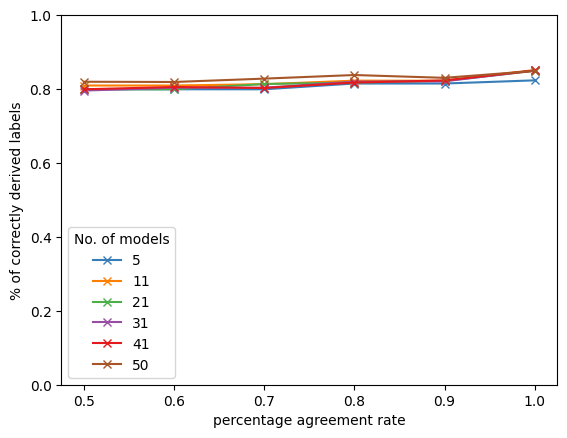

In [512]:
fig_2 = plt.figure()
# x = 
plt.plot(derived_label_match_results[key_1].keys(), derived_label_match_results[key_1].values(), marker='x', color=colors[0], label=key_1)
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color=, alpha=0.6)

plt.plot(derived_label_match_results[key_2].keys(), derived_label_match_results[key_2].values(), marker='x', color=colors[1], label=key_2)
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color=colors[1], alpha=0.6)

plt.plot(derived_label_match_results[key_3].keys(), derived_label_match_results[key_3].values(), marker='x', color=colors[2], label=key_3)
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color=colors[2], alpha=0.6)

plt.plot(derived_label_match_results[key_4].keys(), derived_label_match_results[key_4].values(), marker='x', color=colors[3], label=key_4)
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color=colors[3], alpha=0.6)

plt.plot(derived_label_match_results[key_5].keys(), derived_label_match_results[key_5].values(), marker='x', color=colors[4], label=key_5)
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color=colors[4], alpha=0.6)

plt.plot(derived_label_match_results[key_6].keys(), derived_label_match_results[key_6].values(), marker='x', color=colors[5], label=key_6)
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color=colors[5], alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
# plt.xlabel("% of models agreed")
plt.xlabel("percentage agreement rate")

plt.ylim(0, 1)
plt.ylabel("% of correctly derived labels")
plt.legend(title='No. of models')
# plt.title("{}".format(model_name+": Labels Match for "+derived_dataset))

plt.savefig(path+dataset_combo+"_"+model_name+'_perc_Labels_Match_Forward_Expr.png', dpi=600)

In [513]:
# max_val = 0
# min_val = 999999
# for key in fwd_exp_results.keys():
#     # val = 
#     if max_val < max(fwd_exp_results[key].values()):
#         max_val = max(fwd_exp_results[key].values())
    
#     if min_val > min(fwd_exp_results[key].values()):
#         min_val = min(fwd_exp_results[key].values())

#     # print(max(fwd_exp_results[key].values()))

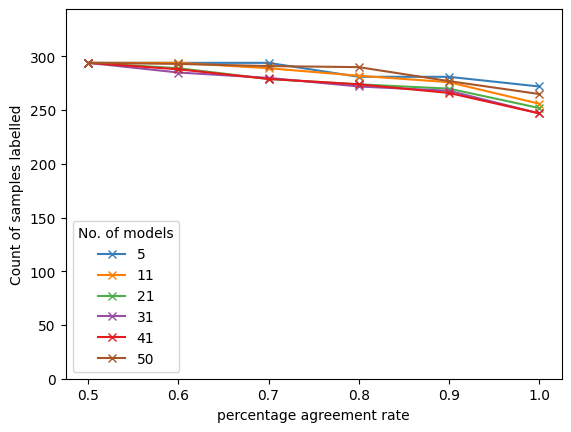

In [514]:
if count_plot_print:
    fig_1 = plt.figure()
    # x = 
    plt.plot(fwd_exp_results[key_1].keys(), fwd_exp_results[key_1].values(), marker='x', color=colors[0], label=key_1)
    # plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color=, alpha=0.6)

    plt.plot(fwd_exp_results[key_2].keys(), fwd_exp_results[key_2].values(), marker='x', color=colors[1], label=key_2)
    # plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color=colors[1], alpha=0.6)

    plt.plot(fwd_exp_results[key_3].keys(), fwd_exp_results[key_3].values(), marker='x', color=colors[2], label=key_3)
    # plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color=colors[2], alpha=0.6)

    plt.plot(fwd_exp_results[key_4].keys(), fwd_exp_results[key_4].values(), marker='x', color=colors[3], label=key_4)
    # plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color=colors[3], alpha=0.6)

    plt.plot(fwd_exp_results[key_5].keys(), fwd_exp_results[key_5].values(), marker='x', color=colors[4], label=key_5)
    # plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color=colors[4], alpha=0.6)

    plt.plot(fwd_exp_results[key_6].keys(), fwd_exp_results[key_6].values(), marker='x', color=colors[5], label=key_6)
    # plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color=colors[5], alpha=0.6)

    plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    plt.xlabel("percentage agreement rate")

    plt.ylim(0, len_derived+50)
    plt.ylabel("Count of samples labelled")
    plt.legend(title='No. of models')
    # plt.title("{}".format(model_name+": ("+derived_dataset+') Samples Labelled Out of '+str(derived_dataset_count)))

    fname = path+dataset_combo+"_"+model_name+"_"+derived_dataset+'_Forward_Expr_Samples_Labelled.png'

    plt.savefig(fname, dpi=600)

In [515]:
count_correctly_labelled

{5: {0.5: 235, 0.6: 235, 0.7: 235, 0.8: 229, 0.9: 229, 1.0: 224},
 11: {0.5: 238, 0.6: 238, 0.7: 235, 0.8: 232, 0.9: 227, 1.0: 218},
 21: {0.5: 235, 0.6: 231, 0.7: 227, 0.8: 224, 0.9: 222, 1.0: 214},
 31: {0.5: 234, 0.6: 229, 0.7: 225, 0.8: 223, 0.9: 220, 1.0: 210},
 41: {0.5: 235, 0.6: 232, 0.7: 224, 0.8: 224, 0.9: 219, 1.0: 210},
 50: {0.5: 241, 0.6: 240, 0.7: 241, 0.8: 243, 0.9: 230, 1.0: 225}}

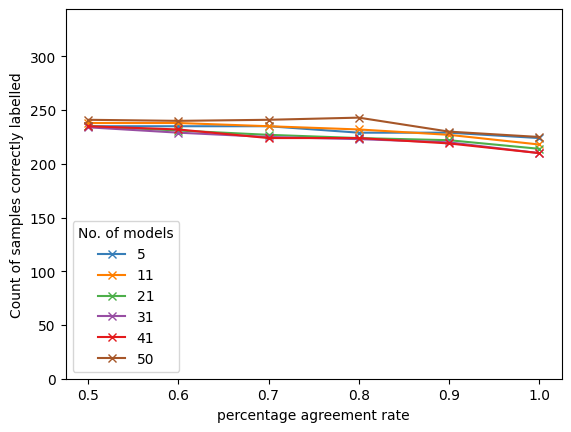

In [516]:
# count_correctly_labelled
if count_plot_print:

    fig = plt.figure()
    # x = 
    plt.plot(count_correctly_labelled[key_1].keys(), count_correctly_labelled[key_1].values(), marker='x', color=colors[0], label=key_1)
    # plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color=colors[0], alpha=0.6)

    plt.plot(count_correctly_labelled[key_2].keys(), count_correctly_labelled[key_2].values(), marker='x', color=colors[1], label=key_2)
    # plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color=colors[1], alpha=0.6)

    plt.plot(count_correctly_labelled[key_3].keys(), count_correctly_labelled[key_3].values(), marker='x', color=colors[2], label=key_3)
    # plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color=colors[2], alpha=0.6)

    plt.plot(count_correctly_labelled[key_4].keys(), count_correctly_labelled[key_4].values(), marker='x', color=colors[3], label=key_4)
    # plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color=colors[3], alpha=0.6)

    plt.plot(count_correctly_labelled[key_5].keys(), count_correctly_labelled[key_5].values(), marker='x', color=colors[4], label=key_5)
    # plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color=colors[4], alpha=0.6)

    plt.plot(count_correctly_labelled[key_6].keys(), count_correctly_labelled[key_6].values(), marker='x', color=colors[5], label=key_6)
    # plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color=colors[5], alpha=0.6)

    plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    plt.xlabel("percentage agreement rate")

    plt.ylim([0, len_derived+50])
    plt.ylabel("Count of samples correctly labelled")
    plt.legend(title='No. of models')
    # plt.title("{}".format(model_name+": ("+derived_dataset+') Samples Correctly Labelled'))

    plt.savefig(path+dataset_combo+"_"+model_name+"_"+derived_dataset+'_Forward_Expr_Samples_Correctly_Labelled.png', dpi=600)

In [517]:
model_name, bkd_exp_results

('LR',
 {5: {0.5: 303, 0.6: 303, 0.7: 303, 0.8: 303, 0.9: 303, 1.0: 299},
  11: {0.5: 303, 0.6: 303, 0.7: 303, 0.8: 302, 0.9: 301, 1.0: 298},
  21: {0.5: 303, 0.6: 303, 0.7: 302, 0.8: 301, 0.9: 299, 1.0: 297},
  31: {0.5: 303, 0.6: 303, 0.7: 300, 0.8: 302, 0.9: 302, 1.0: 295},
  41: {0.5: 303, 0.6: 303, 0.7: 301, 0.8: 303, 0.9: 300, 1.0: 294},
  50: {0.5: 303, 0.6: 303, 0.7: 302, 0.8: 301, 0.9: 292, 1.0: 290}})

Save at ./Final_Results/HD/CL_HG/LR/CL_HG_LR_Cleveland_Reverse_Expr_Samples_Labelled.png


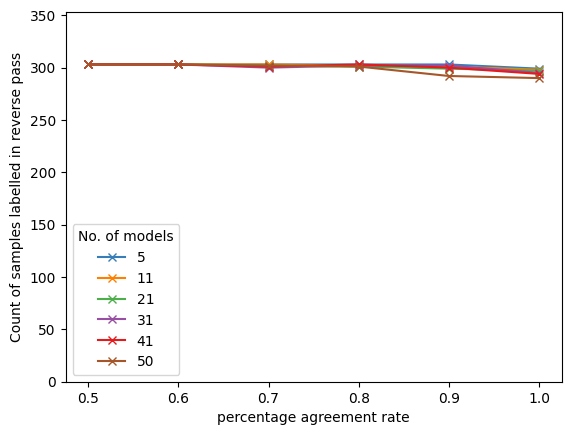

In [518]:
if count_plot_print:
    fig_3 = plt.figure()
    # x = 
    plt.plot(bkd_exp_results[key_1].keys(), bkd_exp_results[key_1].values(), marker='x', color=colors[0], label=key_1)
    # plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color=colors[0], alpha=0.6)

    plt.plot(bkd_exp_results[key_2].keys(), bkd_exp_results[key_2].values(), marker='x', color=colors[1], label=key_2)
    # plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color=colors[1], alpha=0.6)

    plt.plot(bkd_exp_results[key_3].keys(), bkd_exp_results[key_3].values(), marker='x', color=colors[2], label=key_3)
    # plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color=colors[2], alpha=0.6)

    plt.plot(bkd_exp_results[key_4].keys(), bkd_exp_results[key_4].values(), marker='x', color=colors[3], label=key_4)
    # plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color=colors[3], alpha=0.6)

    plt.plot(bkd_exp_results[key_5].keys(), bkd_exp_results[key_5].values(), marker='x', color=colors[4], label=key_5)
    # plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color=colors[4], alpha=0.6)

    plt.plot(bkd_exp_results[key_6].keys(), bkd_exp_results[key_6].values(), marker='x', color=colors[5], label=key_6)
    # plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color=colors[5], alpha=0.6)

    plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    plt.xlabel("percentage agreement rate")

    plt.ylim(0, len_base+50)
    plt.ylabel("Count of samples labelled in reverse pass")
    plt.legend(title='No. of models')
    # plt.title("{}".format(model_name+": ("+base_dataset+') Samples Labelled Out of '+str(base_dataset_count)))

    fname = path+dataset_combo+"_"+model_name+"_"+base_dataset+'_Reverse_Expr_Samples_Labelled.png'
    plt.savefig(fname, dpi=600)
    print(f"Save at {fname}")

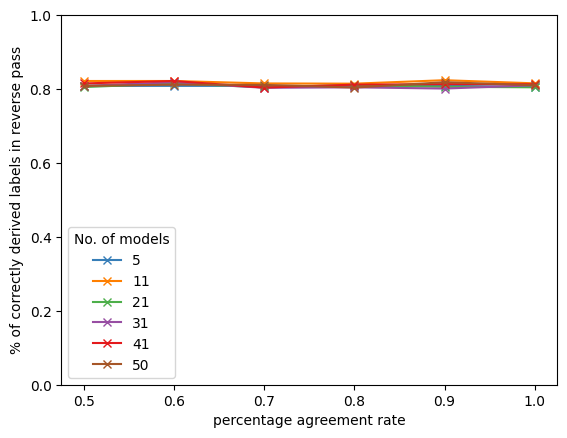

In [519]:
fig_4 = plt.figure()
# x = 
plt.plot(reverse_label_match_original_results[key_1].keys(), reverse_label_match_original_results[key_1].values(), marker='x', color=colors[0], label=key_1)
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color=colors[0], alpha=0.6)

plt.plot(reverse_label_match_original_results[key_2].keys(), reverse_label_match_original_results[key_2].values(), marker='x', color=colors[1], label=key_2)
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color=colors[1], alpha=0.6)

plt.plot(reverse_label_match_original_results[key_3].keys(), reverse_label_match_original_results[key_3].values(), marker='x', color=colors[2], label=key_3)
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color=colors[2], alpha=0.6)

plt.plot(reverse_label_match_original_results[key_4].keys(), reverse_label_match_original_results[key_4].values(), marker='x', color=colors[3], label=key_4)
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color=colors[3], alpha=0.6)

plt.plot(reverse_label_match_original_results[key_5].keys(), reverse_label_match_original_results[key_5].values(), marker='x', color=colors[4], label=key_5)
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color=colors[4], alpha=0.6)

plt.plot(reverse_label_match_original_results[key_6].keys(), reverse_label_match_original_results[key_6].values(), marker='x', color=colors[5], label=key_6)
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color=colors[5], alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("percentage agreement rate")

plt.ylim(0, 1)
plt.ylabel("% of correctly derived labels in reverse pass")
plt.legend(title='No. of models')
# plt.title("{}".format(model_name+": ("+base_dataset+') Samples Labelled Out of '+str(base_dataset_count)))

plt.savefig(path+dataset_combo+"_"+model_name+"_"+base_dataset+'_Reverse_Label_Match_Original.png', dpi=600)

In [520]:
print(f"Dataset: {dataset_name}, model: {model_name}")

Dataset: HD, model: LR


Dataset: HD, model: LR


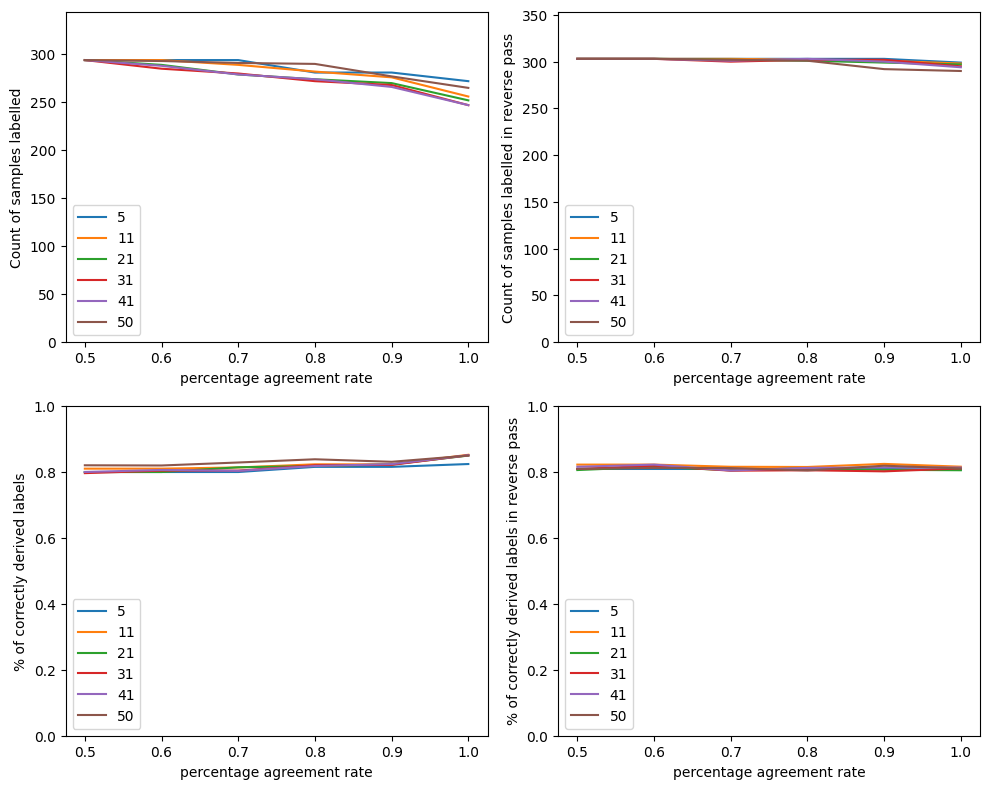

In [522]:
# Create a new figure for arranging all the subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))  # 2x2 grid layout

original_figs = [fig_1, fig_3, fig_2, fig_4]

# # Transfer content from existing figures to subplots
for ax, original_fig in zip(axs.flatten(), original_figs):
    original_ax = original_fig.axes[0]  # Get the first axes of the original figure
    for line in original_ax.get_lines():  # Copy lines
        ax.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
    # Copy title, labels, and legend
    ax.set_title(original_ax.get_title())
    ax.set_xlabel(original_ax.get_xlabel())
    ax.set_ylabel(original_ax.get_ylabel())
    ax.legend()
    ax.set_xlim(original_ax.get_xlim())
    ax.set_ylim(original_ax.get_ylim())

print(f"Dataset: {dataset_name}, model: {model_name}")
plt.tight_layout()
plt.show()